# 가구 GLB 생성기 (furniture_glb_maker)

가구 사진 1장 -> TripoSR 3D 복원 -> 방향 보정 -> 실측 스케일(미터) -> GLB 저장.

**이 노트북은 dust3r_pipeline 과 별도 세션에서 실행한다.**
TripoSR 의존성(requirements.txt)이 DUSt3R 세션의 torch/기타 패키지와 충돌할 수 있어서
같은 런타임에 두 파이프라인을 올리면 안 된다.

산출물 규약:
- 저장 위치: `/content/drive/MyDrive/furniture_glb/{이름}.glb`
- 단위: 미터 (m)
- 좌표: 바닥 Y=0, X/Z 중앙 정렬, +Y 위 방향
- vertex color 포함

dust3r_pipeline_try 의 "메시 뷰어 v2" 셀이 이 폴더의 GLB를 전부 읽어
HTML 뷰어에 내장하고, 뷰어 안에서 버튼 -> 바닥 클릭으로 배치한다.
(방은 raw 단위이므로 뷰어가 1/SCALE 로 자동 변환한다. 여기서는 미터만 지키면 된다.)

가구를 여러 개 만들 때는 2번(이미지 업로드)부터 다시 실행하면 된다.

## 0. Drive 마운트 + 저장 폴더

In [2]:
# Drive 마운트 및 가구 GLB 저장 폴더 생성
import os
from google.colab import drive

drive.mount("/content/drive")

FURN_DIR = "/content/drive/Othercomputers/내 노트북/Asac-DL-Team4/02_Data/furniture_glb"
os.makedirs(FURN_DIR, exist_ok=True)

print(f"가구 GLB 저장 폴더: {FURN_DIR}")
existing = sorted(f for f in os.listdir(FURN_DIR) if f.endswith(".glb"))
print(f"기존 가구 GLB: {len(existing)}개")
for f in existing:
    print(f"  - {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
가구 GLB 저장 폴더: /content/drive/Othercomputers/내 노트북/Asac-DL-Team4/02_Data/furniture_glb
기존 가구 GLB: 0개


## 1. 설치 + 모델 로드

In [ ]:
!git clone https://github.com/VAST-AI-Research/TripoSR.git
%cd /content/TripoSR
!pip install "setuptools<82"

Cloning into 'TripoSR'...
remote: Enumerating objects: 164, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 164 (delta 64), reused 42 (delta 42), pack-reused 66 (from 1)
Receiving objects: 100% (164/164), 36.71 MiB | 15.31 MiB/s, done.
Resolving deltas: 100% (66/66), done.
/content/TripoSR


In [ ]:
%cd /content/TripoSR
!pip install -r requirements.txt

/content/TripoSR
  Cloning https://github.com/tatsy/torchmcubes.git to /tmp/pip-req-build-aup5vfx_
  Running command git clone --filter=blob:none --quiet https://github.com/tatsy/torchmcubes.git /tmp/pip-req-build-aup5vfx_
  fatal: unable to access 'https://github.com/tatsy/torchmcubes.git/': Failed to connect to github.com port 443 after 135433 ms: Connection timed out
  fatal: unable to access 'https://github.com/tatsy/torchmcubes.git/': Failed to connect to github.com port 443 after 134644 ms: Connection timed out
  fatal: unable to access 'https://github.com/tatsy/torchmcubes.git/': Failed to connect to github.com port 443 after 133688 ms: Connection timed out
  Resolved https://github.com/tatsy/torchmcubes.git to commit 3381600ddc3d2e4d74222f8495866be5fafbace4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 9.1 MB/s eta 0:00:00
INFO: pi

In [ ]:
%cd /content/TripoSR
!pip install onnxruntime
!pip uninstall -y cupy-cuda12x

/content/TripoSR


In [ ]:
import sys
sys.path.insert(0, '/content/TripoSR')

import torch
import numpy as np
import trimesh
from PIL import Image

from tsr.system import TSR
from tsr.utils import remove_background, resize_foreground

print('TSR import 성공')
print('torch:', torch.__version__, '| CUDA:', torch.cuda.is_available())

✅ TSR import 성공
torch: 2.11.0+cu128 | CUDA: True


In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'디바이스: {DEVICE}')

model_tsr = TSR.from_pretrained(
    'stabilityai/TripoSR',
    config_name='config.yaml',
    weight_name='model.ckpt',
)
model_tsr.to(DEVICE)
model_tsr.renderer.set_chunk_size(8192)

print('모델 로드 완료')

디바이스: cuda
✅ 모델 로드 완료


## 2. 가구 이미지 업로드 + 배경 제거

가구를 추가로 만들 때는 여기부터 다시 실행.

Saving Queen_bed.png to Queen_bed.png
✅ 업로드: Queen_bed.png
✅ 배경 제거 완료: (632, 552)


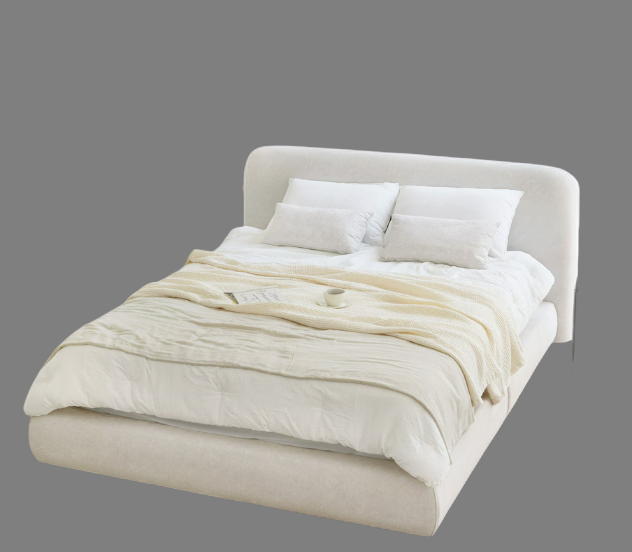

In [ ]:
# 가구 이미지 업로드 + 배경 제거
from google.colab import files
import io, os
from rembg import remove as rembg_remove

uploaded = files.upload()
filename = list(uploaded.keys())[0]
PRODUCT_NAME = os.path.splitext(filename)[0]

input_image = Image.open(io.BytesIO(uploaded[filename])).convert("RGBA")

# 배경 제거
img_nobg = rembg_remove(input_image)

# 회색 배경 합성
img_arr = np.array(img_nobg).astype(np.float32) / 255.0
img_arr = img_arr[:,:,:3] * img_arr[:,:,3:4] + (1 - img_arr[:,:,3:4]) * 0.5
processed_image = Image.fromarray((img_arr * 255.0).astype(np.uint8))

print(f"업로드: {filename}")
print(f"배경 제거 완료: {processed_image.size}")
processed_image

## 3. TripoSR 3D 추론

In [ ]:
# 3D 추론 + 메시 추출 + GLB 저장
import time

start = time.time()
with torch.no_grad():
    scene_codes = model_tsr([processed_image], device=DEVICE)
print(f"추론 완료: {time.time()-start:.1f}초")
mesh = model_tsr.extract_mesh(scene_codes, True, resolution=256)[0]

# GLB 저장
raw_glb = f"/content/{PRODUCT_NAME}_raw.glb"
mesh.export(raw_glb)

bbox = mesh.bounds
raw_size = bbox[1] - bbox[0]
print(f"✅ GLB 저장: {raw_glb}")
print(f"📐 원본 크기 — X: {raw_size[0]:.4f}  Y: {raw_size[1]:.4f}  Z: {raw_size[2]:.4f}")
print(f"   버텍스: {len(mesh.vertices):,} | 면: {len(mesh.faces):,}")


🔄 3D 추론 중...
✅ 추론 완료: 6.9초
🔄 메시 추출 중...
✅ GLB 저장: /content/Queen_bed_raw.glb
📐 원본 크기 — X: 1.0702  Y: 1.0968  Z: 0.8244
   버텍스: 79,083 | 면: 157,829


## 4. 방향 자동 보정 (PCA)

TripoSR 출력은 축 방향이 제각각이라 PCA 주축 + 바닥 지지율로 위쪽(Y)을 추정한다.
vertex color는 정점 순서가 바뀌지 않으므로 그대로 유지된다.

In [ ]:
# 방향 자동 보정
import numpy as np
import trimesh

def auto_orient_upright(src_mesh):
    m = src_mesh.copy()
    verts = m.vertices.copy()
    center = verts.mean(axis=0)
    verts_c = verts - center

    # PCA 주축 계산
    cov = np.cov(verts_c.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, order]
    if np.linalg.det(eigvecs) < 0:
        eigvecs[:, -1] *= -1
    verts_pca = verts_c @ eigvecs

    # 바닥으로 가장 그럴듯한 축 찾기 (하단 5% 구간에 포인트가 가장 많은 축)
    best_axis, best_score = 0, -1.0
    for axis in range(3):
        v = verts_pca[:, axis]
        lo, hi = v.min(), v.max()
        span = hi - lo if hi > lo else 1e-9
        thresh = lo + 0.05 * span
        support = float(np.mean(v < thresh))
        if support > best_score:
            best_score = support
            best_axis = axis

    other_axes = [a for a in range(3) if a != best_axis]
    perm = [other_axes[0], best_axis, other_axes[1]]  # X, Y(up), Z
    verts_final = verts_pca[:, perm]

    # 바닥 Y=0, X/Z 중앙 정렬
    verts_final[:, 1] -= verts_final[:, 1].min()
    verts_final[:, 0] -= (verts_final[:, 0].max() + verts_final[:, 0].min()) / 2
    verts_final[:, 2] -= (verts_final[:, 2].max() + verts_final[:, 2].min()) / 2

    m.vertices = verts_final
    m.fix_normals()
    return m, best_score

mesh_oriented, up_confidence = auto_orient_upright(mesh)
oriented_size = mesh_oriented.bounds[1] - mesh_oriented.bounds[0]

print(f"자동 방향 보정 완료 (바닥면 신뢰도: {up_confidence:.1%})")
if up_confidence < 0.15:
    print("신뢰도 낮음 — 다음 셀 뷰어에서 방향을 꼭 확인할 것")
print(f"보정 후 크기 — X: {oriented_size[0]:.4f}  Y: {oriented_size[1]:.4f}  Z: {oriented_size[2]:.4f}")

자동 방향 보정 완료 (바닥면 신뢰도: 9.4%)
신뢰도 낮음 — 다음 셀 뷰어에서 방향을 꼭 확인할 것
보정 후 크기 — X: 1.0297  Y: 0.8520  Z: 0.4934


## 5. 방향 확인용 뷰어

가구가 바닥에 제대로 서 있는지 확인한다. 이상하면 슬라이더로 맞추고
아래 라디안값을 다음 셀 `fine_tune_rot` 에 입력.

**이 셀 출력은 노트북 저장 전에 지울 것 (Edit > Clear output).**

In [ ]:
# 방향 확인용 뷰어 (mesh_oriented)
# 뷰어용으로만 면 수를 줄여서 노트북 출력이 무거워지지 않게 한다.
import json
import numpy as np
import trimesh
from IPython.display import display, HTML

VIEW_MAX_FACES = 40000

view_mesh = mesh_oriented
if len(mesh_oriented.faces) > VIEW_MAX_FACES:
    try:
        import fast_simplification
        from scipy.spatial import cKDTree
        v, f = fast_simplification.simplify(
            np.asarray(mesh_oriented.vertices, np.float64),
            np.asarray(mesh_oriented.faces, np.int64),
            target_reduction=1.0 - VIEW_MAX_FACES / len(mesh_oriented.faces),
        )
        view_mesh = trimesh.Trimesh(vertices=v, faces=f, process=False)
        if (hasattr(mesh_oriented.visual, "vertex_colors")
                and mesh_oriented.visual.vertex_colors is not None):
            _, idx = cKDTree(mesh_oriented.vertices).query(v)
            view_mesh.visual.vertex_colors = mesh_oriented.visual.vertex_colors[idx]
        print(f"뷰어용 다운샘플: 면 {len(mesh_oriented.faces):,} -> {len(view_mesh.faces):,}")
    except Exception as e:
        print(f"다운샘플 건너뜀({e}) — 원본 그대로 표시")

verts = view_mesh.vertices.astype(np.float32)
faces = view_mesh.faces.astype(np.uint32).flatten()

if (hasattr(view_mesh.visual, "vertex_colors")
        and view_mesh.visual.vertex_colors is not None
        and len(view_mesh.visual.vertex_colors) == len(verts)):
    colors = (view_mesh.visual.vertex_colors[:, :3] / 255.0).astype(np.float32)
else:
    colors = np.ones((len(verts), 3), dtype=np.float32) * 0.6

normals = view_mesh.vertex_normals.astype(np.float32)

cx, cy, cz = verts.mean(axis=0)
verts_centered = verts - [cx, cy, cz]

r = float(max(view_mesh.bounds[1] - view_mesh.bounds[0])) * 0.9

data = {
    "positions": verts_centered.flatten().tolist(),
    "normals": normals.flatten().tolist(),
    "colors": colors.flatten().tolist(),
    "indices": faces.tolist(),
    "radius": r,
}

html_code = f"""
<div style="display:flex;gap:12px;align-items:flex-start;font-family:sans-serif;">
  <div id="vc" style="width:620px;height:440px;border:1px solid #ccc;position:relative;"></div>

  <div style="width:190px;font-size:12px;color:#333;">
    <div style="font-weight:600;margin-bottom:8px;">메시 회전</div>

    <label>X축: <span id="rxV">0</span>°</label>
    <input type="range" id="rx" min="0" max="360" value="0" step="1" style="width:100%;"><br><br>

    <label>Y축: <span id="ryV">0</span>°</label>
    <input type="range" id="ry" min="0" max="360" value="0" step="1" style="width:100%;"><br><br>

    <label>Z축: <span id="rzV">0</span>°</label>
    <input type="range" id="rz" min="0" max="360" value="0" step="1" style="width:100%;"><br><br>

    <div style="display:flex;flex-wrap:wrap;gap:4px;margin-bottom:10px;">
      <button class="qb" data-axis="x" data-deg="90">X+90</button>
      <button class="qb" data-axis="x" data-deg="-90">X-90</button>
      <button class="qb" data-axis="y" data-deg="90">Y+90</button>
      <button class="qb" data-axis="y" data-deg="-90">Y-90</button>
      <button class="qb" data-axis="z" data-deg="90">Z+90</button>
      <button class="qb" data-axis="z" data-deg="-90">Z-90</button>
      <button id="rst">초기화</button>
    </div>

    <div style="background:#f4f4f4;border-radius:6px;padding:8px;font-family:monospace;font-size:11px;">
      다음 셀에 넣을 라디안값:<br>
      x = <span id="rxR">0</span><br>
      y = <span id="ryR">0</span><br>
      z = <span id="rzR">0</span>
    </div>

    <div style="font-size:11px;color:#777;margin-top:6px;">
      가구가 바닥에 제대로 서 있으면 OK<br>
      드래그: 회전<br>
      스크롤: 줌
    </div>
  </div>
</div>

<script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
<script src="https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/controls/OrbitControls.js"></script>

<script>
(function(){{
  const D = {json.dumps(data)};
  const cont = document.getElementById('vc');

  const scene = new THREE.Scene();
  scene.background = new THREE.Color('#EEEDE9');

  const cam = new THREE.PerspectiveCamera(45, 620 / 440, 0.01, D.radius * 20);
  cam.position.set(D.radius, D.radius * 0.8, D.radius);
  cam.lookAt(0, 0, 0);

  const ren = new THREE.WebGLRenderer({{antialias:true}});
  ren.setSize(620, 440);
  cont.appendChild(ren.domElement);

  const geo = new THREE.BufferGeometry();
  geo.setAttribute('position', new THREE.Float32BufferAttribute(D.positions, 3));
  geo.setAttribute('normal', new THREE.Float32BufferAttribute(D.normals, 3));
  geo.setAttribute('color', new THREE.Float32BufferAttribute(D.colors, 3));
  geo.setIndex(D.indices);

  const mat = new THREE.MeshLambertMaterial({{
    vertexColors:true,
    side:THREE.DoubleSide
  }});

  const grp = new THREE.Group();
  grp.add(new THREE.Mesh(geo, mat));
  scene.add(grp);

  scene.add(new THREE.AmbientLight(0xffffff, 0.6));

  const dl = new THREE.DirectionalLight(0xffffff, 0.8);
  dl.position.set(3, 5, 3);
  scene.add(dl);

  const ctrl = new THREE.OrbitControls(cam, ren.domElement);
  ctrl.enableDamping = true;
  ctrl.dampingFactor = 0.1;

  function loop(){{
    requestAnimationFrame(loop);
    ctrl.update();
    ren.render(scene, cam);
  }}
  loop();

  const rx = document.getElementById('rx');
  const ry = document.getElementById('ry');
  const rz = document.getElementById('rz');

  function upd(){{
    const dx = THREE.MathUtils.degToRad(+rx.value);
    const dy = THREE.MathUtils.degToRad(+ry.value);
    const dz = THREE.MathUtils.degToRad(+rz.value);

    grp.rotation.set(dx, dy, dz);

    document.getElementById('rxV').textContent = rx.value;
    document.getElementById('ryV').textContent = ry.value;
    document.getElementById('rzV').textContent = rz.value;

    document.getElementById('rxR').textContent = dx.toFixed(4);
    document.getElementById('ryR').textContent = dy.toFixed(4);
    document.getElementById('rzR').textContent = dz.toFixed(4);
  }}

  [rx, ry, rz].forEach(s => s.addEventListener('input', upd));

  document.querySelectorAll('.qb').forEach(b => {{
    b.addEventListener('click', () => {{
      const sl = b.dataset.axis === 'x' ? rx : b.dataset.axis === 'y' ? ry : rz;
      let v = (+sl.value + +b.dataset.deg) % 360;
      if (v < 0) v += 360;
      sl.value = v;
      upd();
    }});
  }});

  document.getElementById('rst').addEventListener('click', () => {{
    rx.value = 0;
    ry.value = 0;
    rz.value = 0;
    upd();
  }});

  upd();
}})();
</script>
"""

print(f"{PRODUCT_NAME} 방향 확인 뷰어")
print("가구가 바닥에 제대로 서 있으면 다음 셀로 넘어가면 된다.")
print("방향이 이상하면 슬라이더 조정 후 라디안값을 다음 셀 fine_tune_rot 에 입력.")
display(HTML(html_code))


Output hidden; open in https://colab.research.google.com to view.

## 6. 방향 확정 + 실측 스케일 적용 + 저장

`real_*_cm` 세 값만 가구 실측(제품 스펙)으로 수정하면 된다.
결과는 미터 단위, 바닥 Y=0, X/Z 중앙 정렬 상태로 Drive 폴더에 저장된다.

In [ ]:
# 방향 확정 + 실측 스케일 적용 + 미터 GLB 저장
import trimesh
import numpy as np
import shutil
from google.colab import files

# 위 방향 확인 뷰어에서 나온 라디안값 입력 (방향 괜찮으면 0,0,0 그대로)
fine_tune_rot = {
    "x": 0.0,
    "y": 0.0,
    "z": 4.8171,
}

Rx = trimesh.transformations.rotation_matrix(fine_tune_rot["x"], [1, 0, 0])
Ry = trimesh.transformations.rotation_matrix(fine_tune_rot["y"], [0, 1, 0])
Rz = trimesh.transformations.rotation_matrix(fine_tune_rot["z"], [0, 0, 1])

mesh_final = mesh_oriented.copy()
mesh_final.apply_transform(Rz @ Ry @ Rx)
mesh_final.vertices[:, 1] -= mesh_final.vertices[:, 1].min()

raw_size = mesh_final.bounds[1] - mesh_final.bounds[0]
print("현재 정규화 크기")
print(f"X: {raw_size[0]:.4f}  Y: {raw_size[1]:.4f}  Z: {raw_size[2]:.4f}")

# =========================================================
# 여기만 가구마다 수정. 단위: cm
# X = 가로, Y = 높이, Z = 깊이
# =========================================================
real_x_cm = 205
real_y_cm = 233.5
real_z_cm = 110

sx = real_x_cm / raw_size[0]
sy = real_y_cm / raw_size[1]
sz = real_z_cm / raw_size[2]
print(f"축별 스케일 — sx:{sx:.2f}  sy:{sy:.2f}  sz:{sz:.2f}")

# 실측 cm -> m
meters_mesh = mesh_final.copy()
meters_mesh.apply_scale([sx, sy, sz])
meters_mesh.apply_scale(0.01)

# 바닥 Y=0, X/Z 중앙 재정렬 (스케일 후 다시 보정)
v = meters_mesh.vertices
v[:, 1] -= v[:, 1].min()
v[:, 0] -= (v[:, 0].max() + v[:, 0].min()) / 2
v[:, 2] -= (v[:, 2].max() + v[:, 2].min()) / 2

final_size = meters_mesh.bounds[1] - meters_mesh.bounds[0]
print("최종 크기 (m)")
print(f"X: {final_size[0]:.2f}  Y: {final_size[1]:.2f}  Z: {final_size[2]:.2f}")

# vertex color 확인, 없으면 원본에서 복원
has_vc = (hasattr(meters_mesh.visual, "vertex_colors")
          and meters_mesh.visual.vertex_colors is not None
          and len(meters_mesh.visual.vertex_colors) == len(meters_mesh.vertices))
if not has_vc and len(mesh.vertices) == len(meters_mesh.vertices):
    meters_mesh.visual = trimesh.visual.ColorVisuals(
        mesh=meters_mesh, vertex_colors=mesh.visual.vertex_colors)
    has_vc = True
print(f"vertex color 포함: {has_vc}")

# 저장: Drive 폴더 (뷰어가 읽는 위치) + 로컬 백업
out_path = os.path.join(FURN_DIR, f"{PRODUCT_NAME}.glb")
meters_mesh.export(out_path)
local_path = f"/content/{PRODUCT_NAME}.glb"
shutil.copy(out_path, local_path)

print(f"저장 완료: {out_path} ({os.path.getsize(out_path)/1024:.0f} KB)")
print("dust3r_pipeline_try 의 '메시 뷰어 v2' 셀을 실행하면 라이브러리에 자동 반영된다.")

# 로컬 PC로도 받고 싶으면 주석 해제
# files.download(local_path)

현재 정규화 크기
X: 0.8621  Y: 1.0171  Z: 0.4934
축별 스케일 — sx:237.79  sy:229.58  sz:222.95
최종 크기 (m)
X: 2.05  Y: 2.33  Z: 1.10
vertex color 포함: True
저장 완료: /content/drive/MyDrive/furniture_glb/Queen_bed.glb (3086 KB)
dust3r_pipeline_try 의 '메시 뷰어 v2' 셀을 실행하면 라이브러리에 자동 반영된다.


## 7. 라이브러리 현황 확인

In [ ]:
# 저장된 가구 GLB 목록과 크기 확인
import os
import trimesh

glbs = sorted(f for f in os.listdir(FURN_DIR) if f.endswith(".glb"))
print(f"가구 라이브러리 ({FURN_DIR}): {len(glbs)}개\n")

for f in glbs:
    p = os.path.join(FURN_DIR, f)
    try:
        m = trimesh.load(p, force="mesh")
        s = m.bounds[1] - m.bounds[0]
        print(f"  {f:30s} {os.path.getsize(p)/1024:7.0f} KB  "
              f"X:{s[0]:.2f} Y:{s[1]:.2f} Z:{s[2]:.2f} m")
    except Exception as e:
        print(f"  {f:30s} 로드 실패: {e}")

가구 라이브러리 (/content/drive/MyDrive/furniture_glb): 1개

  Queen_bed.glb                     3086 KB  X:1.80 Y:0.80 Z:0.85 m
